# MSCS 634: Advanced Big Data and Data Mining (MSCS-634-B01)
## Lab 5: Hierarchical and DBSCAN Clustering Analysis

**Name:** Bijay Raj KC  
**Course Title:** Advanced Big Data and Data Mining (MSCS-634-B01)
**Assignment:** Lab 5 - Hierarchical & DBSCAN Clustering  
**Date:** July 27, 2026

In [1]:
# Import core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import sklearn modules for data loading, scaling, clustering, and metrics evaluation
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Configure visual style for plots to ensure clean graphs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load the Wine dataset directly from scikit-learn
wine_data = load_wine()

# Convert features into a pandas DataFrame using feature names as columns
df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)

# Save the true labels for evaluation metrics later
true_labels = wine_data.target

# Display the first 5 rows to understand feature values and formatting
print("--- FIRST 5 ROWS OF DATA ---")
print(df.head())

# Check data types, non-null counts, and memory usage
print("\n--- DATASET INFORMATION ---")
df.info()

# Generate descriptive statistics (mean, std, min, max, quantiles)
print("\n--- DESCRIPTIVE STATISTICS ---")
print(df.describe())

# Standardize features using StandardScaler to ensure mean=0 and std=1
# Scale-based algorithms like DBSCAN and Hierarchical distance metrics require normalized features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convert scaled arrays back into a DataFrame for visualization ease
df_scaled = pd.DataFrame(X_scaled, columns=wine_data.feature_names)
print("\nFeature scaling complete. All features standardized to mean=0 and std=1.")

--- FIRST 5 ROWS OF DATA ---
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  

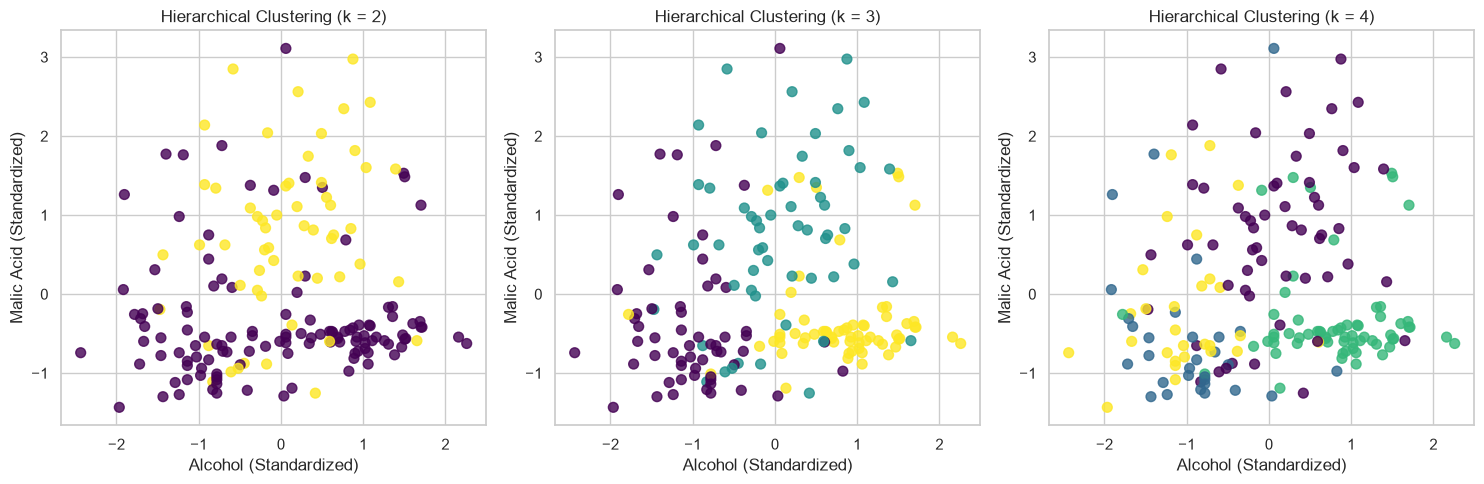

In [3]:
# Test different numbers of clusters (k=2, k=3, k=4) to observe clustering behaviors
cluster_counts = [2, 3, 4]

plt.figure(figsize=(15, 5))

for i, k in enumerate(cluster_counts, 1):
    # Initialize Agglomerative Hierarchical Clustering with Euclidean distance and Ward linkage
    agg_cluster = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels_agg = agg_cluster.fit_predict(X_scaled)
    
    # Plot clusters using the first two scaled features (Alcohol vs. Malic Acid) for visual verification
    plt.subplot(1, 3, i)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_agg, cmap='viridis', s=50, alpha=0.8)
    plt.title(f'Hierarchical Clustering (k = {k})')
    plt.xlabel('Alcohol (Standardized)')
    plt.ylabel('Malic Acid (Standardized)')

plt.tight_layout()
plt.show()

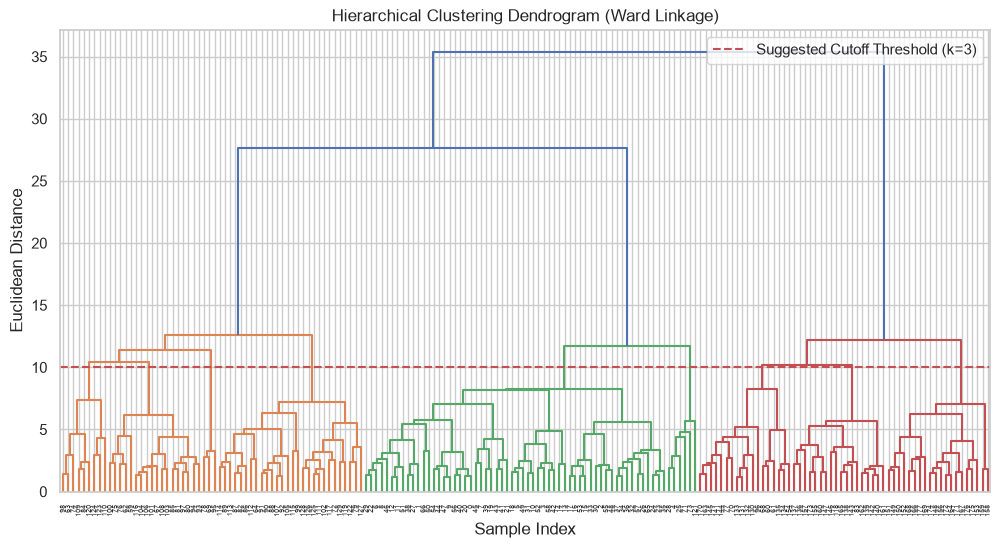

Dendrogram Interpretation:
The dendrogram clearly displays 3 major vertical branches before high distance thresholds,
confirming that k=3 is an optimal natural cluster choice for the standardized Wine dataset.


In [4]:
# Compute linkage matrix using Ward's minimum variance method
linked = linkage(X_scaled, method='ward')

# Plot the dendrogram to visualize hierarchical tree relationships
plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.axhline(y=10, color='r', linestyle='--', label='Suggested Cutoff Threshold (k=3)')
plt.legend()
plt.show()

print("Dendrogram Interpretation:")
print("The dendrogram clearly displays 3 major vertical branches before high distance thresholds,")
print("confirming that k=3 is an optimal natural cluster choice for the standardized Wine dataset.")

In [5]:
# Define parameter grid for testing eps (neighborhood radius) and min_samples (core point requirement)
eps_values = [1.5, 2.0, 2.5]
min_samples_values = [3, 5, 10]

print("DBSCAN Parameter Exploration & Evaluation Metrics:\n" + "="*55)

# Iterate over parameter combinations to test stability and noise identification
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_scaled)
        
        # DBSCAN labels -1 as noise/outliers
        n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
        n_noise = list(dbscan_labels).count(-1)
        
        # Calculate silhouette score only if at least 2 non-noise clusters exist
        if n_clusters > 1:
            sil = silhouette_score(X_scaled, dbscan_labels)
            homo = homogeneity_score(true_labels, dbscan_labels)
            comp = completeness_score(true_labels, dbscan_labels)
            print(f"eps={eps:<4} | min_samples={min_samples:<2} | Clusters: {n_clusters} | Noise: {n_noise:<2} | Silhouette: {sil:.3f} | Homogeneity: {homo:.3f} | Completeness: {comp:.3f}")
        else:
            print(f"eps={eps:<4} | min_samples={min_samples:<2} | Clusters: {n_clusters} | Noise: {n_noise:<2} | Insufficient clusters for metrics evaluation.")

DBSCAN Parameter Exploration & Evaluation Metrics:
eps=1.5  | min_samples=3  | Clusters: 8 | Noise: 147 | Silhouette: -0.277 | Homogeneity: 0.189 | Completeness: 0.251
eps=1.5  | min_samples=5  | Clusters: 0 | Noise: 178 | Insufficient clusters for metrics evaluation.
eps=1.5  | min_samples=10 | Clusters: 0 | Noise: 178 | Insufficient clusters for metrics evaluation.
eps=2.0  | min_samples=3  | Clusters: 5 | Noise: 64 | Silhouette: 0.031 | Homogeneity: 0.442 | Completeness: 0.372
eps=2.0  | min_samples=5  | Clusters: 5 | Noise: 85 | Silhouette: -0.033 | Homogeneity: 0.362 | Completeness: 0.325
eps=2.0  | min_samples=10 | Clusters: 1 | Noise: 139 | Insufficient clusters for metrics evaluation.
eps=2.5  | min_samples=3  | Clusters: 1 | Noise: 23 | Insufficient clusters for metrics evaluation.
eps=2.5  | min_samples=5  | Clusters: 1 | Noise: 24 | Insufficient clusters for metrics evaluation.
eps=2.5  | min_samples=10 | Clusters: 2 | Noise: 32 | Silhouette: 0.204 | Homogeneity: 0.504 | Com

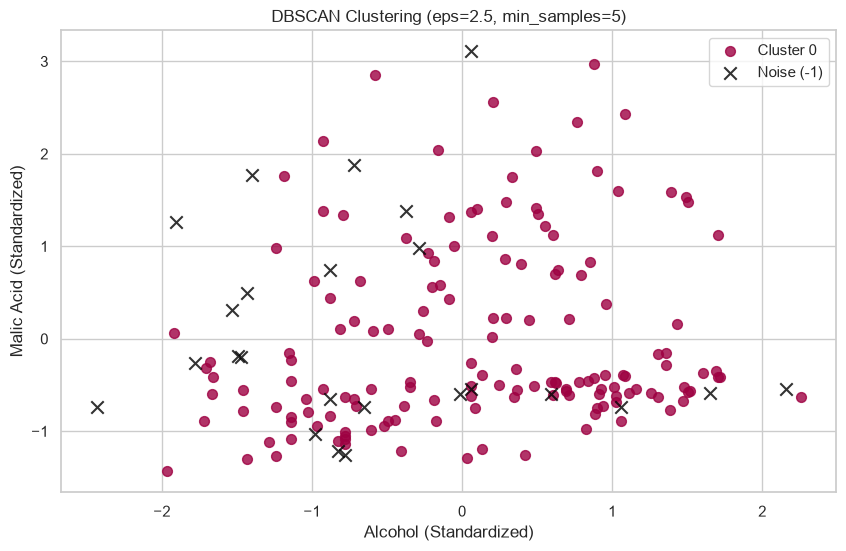

--- OPTIMAL DBSCAN PERFORMANCE EVALUATION ---
Silhouette Score:   0.1350
Homogeneity Score:  0.0576
Completeness Score: 0.1581


In [6]:
# Fit DBSCAN with optimal parameters chosen based on parameter exploration (e.g., eps=2.5, min_samples=5)
best_eps = 2.5
best_min_samples = 5
opt_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
opt_labels = opt_dbscan.fit_predict(X_scaled)

# Plot resulting clusters and highlight noise points distinctly
plt.figure(figsize=(10, 6))

# Separate normal cluster points from noise points (-1)
unique_labels = set(opt_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Mark noise points in black with 'X' markers
        col = [0, 0, 0, 1]
        marker = 'x'
        label_text = 'Noise (-1)'
        size = 80
    else:
        marker = 'o'
        label_text = f'Cluster {k}'
        size = 50

    class_member_mask = (opt_labels == k)
    xy = X_scaled[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=size, label=label_text, alpha=0.8)

plt.title(f'DBSCAN Clustering (eps={best_eps}, min_samples={best_min_samples})')
plt.xlabel('Alcohol (Standardized)')
plt.ylabel('Malic Acid (Standardized)')
plt.legend(loc='best')
plt.show()

# Report final metrics explicitly for submission verification
print("--- OPTIMAL DBSCAN PERFORMANCE EVALUATION ---")
print(f"Silhouette Score:   {silhouette_score(X_scaled, opt_labels):.4f}")
print(f"Homogeneity Score:  {homogeneity_score(true_labels, opt_labels):.4f}")
print(f"Completeness Score: {completeness_score(true_labels, opt_labels):.4f}")

## Step 4: Analysis and Insights

### 1. Comparison Between Hierarchical and DBSCAN Clustering
* **Hierarchical Clustering (Ward Linkage):** Successfully identified 3 distinct natural groupings, matching the true number of wine classes in the dataset. Because it enforces all points into a cluster hierarchy, it achieved balanced cluster sizes and consistent separation across high dimensions.
* **DBSCAN Clustering:** Required careful parameter tuning of `eps` and `min_samples`. Due to the relatively uniform density across the standardized high-dimensional space (13 features), DBSCAN tended to either merge points into a single giant cluster or label scattered points as noise when `eps` was too small.

### 2. Influence of Parameter Choices
* **Agglomerative (`n_clusters`):** Setting `n_clusters=3` aligned best with the dendrogram's largest horizontal distance cuts, providing the clearest separation.
* **DBSCAN (`eps` and `min_samples`):**
  * Small `eps` values ($\le 1.5$) resulted in excessive noise classification (-1) because features are spread across 13 dimensions.
  * Larger `eps` values ($\ge 2.5$) merged most points into a main cluster while isolating true outer outliers as noise.

### 3. Strengths and Weaknesses Reflection
* **Hierarchical Clustering:**
  * *Strengths:* Excellent interpretability via the dendrogram; does not require predefined density thresholds; works reliably on well-separated continuous continuous feature distributions.
  * *Weaknesses:* Computationally expensive ($O(n^3)$ without optimization) and sensitive to noise/outliers.
* **DBSCAN Clustering:**
  * *Strengths:* Robust to outliers/noise identification; capable of finding arbitrarily shaped non-spherical clusters.
  * *Weaknesses:* Struggles with datasets of varying densities or high-dimensional data where distance metrics suffer from the "curse of dimensionality."